In [1]:
import os
from utils import glob_val

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\acer\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
c:\Users\acer\miniconda3\envs\nlp\lib\site-packages\pymorphy2\analyzer.py:114: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Структура папок проверена


# Download

In [2]:
from zipfile import ZipFile
from urllib.request import urlopen
from io import BytesIO

os.makedirs(glob_val.DATA_DIR, exist_ok=True)

with urlopen(glob_val.URL_DOWNLOAD_DATA) as resp:
    with ZipFile(BytesIO(resp.read())) as zf:
        zf.extractall(glob_val.DATA_DIR)

print(f"Распаковка завершена. Файлы в папке {glob_val.DATA_DIR}:")
print(os.listdir(glob_val.DATA_DIR))

KeyboardInterrupt: 

# Load

In [2]:
import pandas as pd

df = pd.read_csv(f'{glob_val.DATA_DIR}/leroy.csv')
df.head()

,category_1,category_2,category_3,name,madein,art,price
0,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Knauf Ротбанд 30 кг,Китай,10073940,445
1,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Волма Слой 30 кг,Китай,11313264,368
2,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Лучшая Цена 30 кг,Китай,14238108,235
3,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Unis Теплон 30 кг,Китай,12639223,326
4,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Axton 30 кг,Китай,13857185,292


Удалим дубликаты и пустые строчки

In [3]:
print(f'Размер до очистки:    {df.shape[0]}')
df = df.drop_duplicates().dropna()
print(f'Размер после очистки: {df.shape[0]}')

Размер до очистки:    358865
Размер после очистки: 358475


Выведем статистику

In [4]:
print('Статистика:')
for column in df.columns:
    if column == 'name':
        continue
    print(f'\nПараметр: {column}')
    column_unique = df[column].unique()
    print(f'* Кол уникальные значения: {len(column_unique)}')
    print(f'* Уникальные значения: {column_unique[:5]}')

Статистика:

Параметр: category_1
* Кол уникальные значения: 16
* Уникальные значения: ['Стройматериалы' 'Столярные изделия' 'Окна и двери' 'Электротовары'
 'Инструменты']

Параметр: category_2
* Кол уникальные значения: 172
* Уникальные значения: ['Сухие смеси и грунтовки' 'Листовые материалы' 'Блоки для строительства'
 'Изоляционные материалы' 'Кровля']

Параметр: category_3
* Кол уникальные значения: 1236
* Уникальные значения: ['Штукатурки' 'Шпаклёвки' 'Смеси для пола' 'Грунтовки'
 'Штукатурные профили и маяки']

Параметр: madein
* Кол уникальные значения: 1
* Уникальные значения: ['Китай']

Параметр: art
* Кол уникальные значения: 23869
* Уникальные значения: [10073940 11313264 14238108 12639223 13857185]

Параметр: price
* Кол уникальные значения: 5316
* Уникальные значения: ['445' '368' '235' '326' '292']


Удалим столбцы:
* мест производства, он в нашем случае не на что не влияет
* артикль, но есть возможность, что в нём есть некая связь с категориями (протестируем, это в другой раз)
* цена, не стоит забывать, что для улучшения модели мы могли бы использовать цену для улучшения качества при предсказании катгорий "3-го уровня"

In [5]:
cache_columns = ['madein', 'art', 'price']

df = df.drop(cache_columns, axis=1)
df.head()

,category_1,category_2,category_3,name
0,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Knauf Ротбанд 30 кг
1,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Волма Слой 30 кг
2,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Лучшая Цена 30 кг
3,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Unis Теплон 30 кг
4,Стройматериалы,Сухие смеси и грунтовки,Штукатурки,Штукатурка гипсовая Axton 30 кг


d:\code\local\nlp\03\utils\visualization.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_data.values, y=plot_data.index, palette="mako")


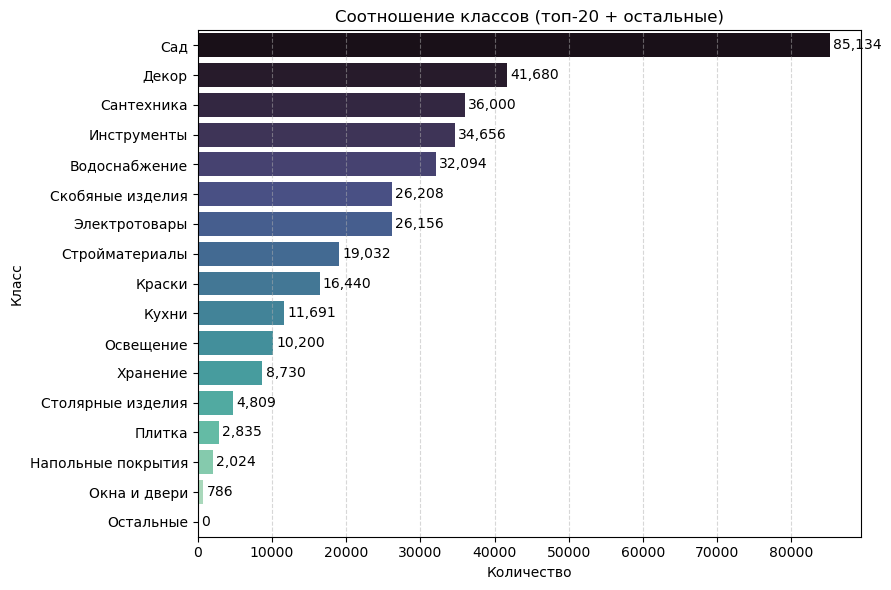

In [6]:
from utils.visualization import plot_top_n_plus_other

plot_top_n_plus_other(df['category_1'].value_counts())

In [7]:
from utils.target_proc import get_info

get_info(df['category_2'])

Всего уникальных значений: 172
Всего записей: 358,475

Топ-30 классов:
  Сумма:        112,014
  Среднее:      3733.8
  Мин / Макс:   2960 / 4056

Хвост (последние 30 классов):
  Сумма:        23,081
  Среднее:      769.4
  Мин / Макс:   393 / 1299

Доля топ-30:    31.2%
Доля хвоста (последние 30):    6.4%
Для покрытия ≥90% данных нужно: 133 классов


In [8]:
get_info(df['category_3'])

Всего уникальных значений: 1236
Всего записей: 358,475

Топ-30 классов:
  Сумма:        18,900
  Среднее:      630.0
  Мин / Макс:   630 / 630

Хвост (последние 30 классов):
  Сумма:        426
  Среднее:      14.2
  Мин / Макс:   4 / 24

Доля топ-30:     5.3%
Доля хвоста (последние 30):    0.1%
Для покрытия ≥90% данных нужно: 855 классов


Итог:
 Мы имеем сильный дисбаланс всех классов.

In [9]:
from sklearn.model_selection import train_test_split

categories = ['category_1', 'category_2', 'category_3']
X_train, X_test, y_train, y_test = train_test_split(df.drop(categories, axis=1), df[categories], test_size=0.15, random_state=glob_val.RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.2, random_state=glob_val.RANDOM_STATE)

Сохраняем все категории, чтоб у нас была возможность усложнять модель предсказания

In [10]:
print('Train:')
print(f'* x: {X_train.shape}')
print(f'* y: {y_train.shape}')
print('Val:')
print(f'* x: {X_val.shape}')
print(f'* y: {y_val.shape}')
print('Test:')
print(f'* x: {X_test.shape}')
print(f'* y: {y_test.shape}')

Train:
* x: (304703, 1)
* y: (304703, 3)
Val:
* x: (43017, 1)
* y: (43017, 3)
Test:
* x: (10755, 1)
* y: (10755, 3)


Сохраним все возможные варианты кодирования категорий и заменим на числовые значения, значения в категориях.

In [11]:
from utils import target_proc

y_data = [y_train, y_val, y_test]
target_proc.all_processing(y_data, categories)

🏁 Начало кодировки.
🟩 Словарь таргетов сохранён. Path:data/target/category_1.json
🍋‍🟩 Таргеты закодированны.
🏁 Начало кодировки.
🟩 Словарь таргетов сохранён. Path:data/target/category_2.json
🍋‍🟩 Таргеты закодированны.
🏁 Начало кодировки.
🟩 Словарь таргетов сохранён. Path:data/target/category_3.json
🍋‍🟩 Таргеты закодированны.


Закодируем столбцы

In [12]:
os.makedirs(f'{glob_val.X_DATA_DIR}', exist_ok=True)

X_train.to_csv(f'{glob_val.X_DATA_DIR}/x_train_str.csv', index=False)
X_val.to_csv(f'{glob_val.X_DATA_DIR}/x_val_str.csv', index=False)
X_test.to_csv(f'{glob_val.X_DATA_DIR}/x_test_str.csv', index=False)

y_train.to_csv(f'{glob_val.TARGET_DIR}/y_train.csv', index=False)
y_val.to_csv(f'{glob_val.TARGET_DIR}/y_val.csv', index=False)
y_test.to_csv(f'{glob_val.TARGET_DIR}/y_test.csv', index=False)